In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    num01 : int
    num02 : int
    final : int
    operation01: str
    operation02: str

In [3]:
def add_node(state: AgentState) -> AgentState:
    """The first add node"""
    state['final'] = state['num01'] + state['num02']
    return state

def subtract_node(state: AgentState) -> AgentState:
    """The first subtract node"""
    state['final'] = state['num01'] - state['num02']
    return state
def add_node02(state: AgentState) -> AgentState:
    """The second add node"""
    state['final'] = state['num01'] + state['num02']
    return state

def subtract_node02(state: AgentState) -> AgentState:
    """The second subtract node"""
    state['final'] = state['num01'] - state['num02']
    return state

def condition(state:AgentState) -> AgentState:
    if state['operation01'] == "+":
     return "add_node"
    elif state['operation01'] == "-":
        return "subtract_node"
    
def condition02(state:AgentState) -> AgentState:
    if state['operation02'] == "+":
     return "add_node02"
    elif state['operation02'] == "-":
        return "subtract_node02"

In [4]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)



graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)

graph.add_node("add_node02", add_node02)
graph.add_node("subtract_node02", subtract_node02)

graph.add_node("router", lambda state: state)
graph.add_node("router02", lambda state: state)



graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    condition,
    {
        "add_node": "add_node",
        "subtract_node": "subtract_node",
    }
)



graph.add_edge("add_node", "router02")
graph.add_edge("subtract_node", "router02")



graph.add_conditional_edges(
    "router02",
    condition02,   
    {
        "add_node02": "add_node02",
        "subtract_node02": "subtract_node02",
    }
)



graph.add_edge("add_node02", END)
graph.add_edge("subtract_node02", END)

# Compile
app = graph.compile()

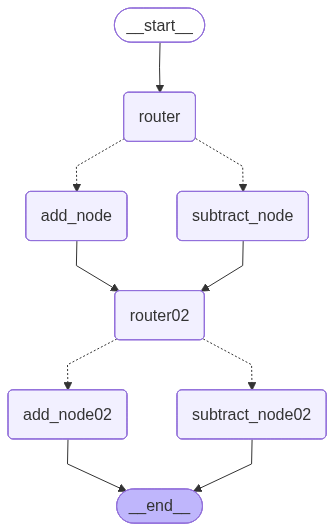

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke(
    {
        "num01": 10,
        "num02": 5,
        "operation01": "+",
        "operation02": "-"
    }
)

print(result)

{'num01': 10, 'num02': 5, 'final': 5, 'operation01': '+', 'operation02': '-'}
